# AMD Screening Case Study v2

This standalone notebook computes and plots the AMD distance matrix across all 71 CIF files
from the Materials Project (MP), Crystallography Open Database (COD), and OQMD.

The original case-study notebook is left unchanged. Results from this version are written to
the `results_v2` directory.

In [ ]:
import sys
from pathlib import Path

import amd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

workspace_root = Path.cwd().resolve()
while workspace_root != workspace_root.parent:
    if (workspace_root / 'Features').is_dir() and (workspace_root / 'Information_Units').is_dir():
        break
    workspace_root = workspace_root.parent

if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from Information_Units.Predictors.Pdd.PddPredictor import PddPredictor

CIF_ROOT = workspace_root / 'tests' / 'fixtures' / 'cif_files'
RESULTS_DIR = workspace_root / 'Features' / 'Materials_Exploration' / 'AmdScreening' / 'analysis' / 'results_v2'

print(f'Workspace root : {workspace_root}')
print(f'MP CIF files   : {len(list((CIF_ROOT / "mp").glob("*.cif")))}')
print(f'COD CIF files  : {len(list((CIF_ROOT / "cod").glob("*.cif")))}')
print(f'OQMD CIF files : {len(list((CIF_ROOT / "oqmd").glob("*.cif")))}')

Workspace root : /home/soe/EMOS
MP CIF files   : 12
COD CIF files  : 20
OQMD CIF files : 39


## Load structures and compute AMD distances

In [ ]:
def load_entries(source):
    directory = CIF_ROOT / source
    return [(f'{source.upper()}/{path.stem}', path)
            for path in sorted(directory.glob('*.cif'), key=lambda p: p.stem)]


all_entries = load_entries('mp') + load_entries('cod') + load_entries('oqmd')
all_labels = [label for label, _ in all_entries]
all_paths = [path for _, path in all_entries]

K = 15
AMD_METRIC = 'euclidean'
predictor = PddPredictor(predictor_name='amd_screening_v2', k=K)
pdd_result = predictor.predict([path.read_text(encoding='utf-8') for path in all_paths])
items = pdd_result.get('results', [])

amd_vectors = {}
invalid_labels = []
for label, item in zip(all_labels, items):
    if item.get('status') == 'ok':
        amd_vectors[label] = np.asarray(item['properties']['pdd_vector'], dtype=float)
    else:
        invalid_labels.append(label)

valid_labels = list(amd_vectors)
valid_vectors = [amd_vectors[label] for label in valid_labels]
valid_matrix = amd.AMD_cdist(valid_vectors, valid_vectors, metric=AMD_METRIC)

amd_matrix = np.full((len(all_labels), len(all_labels)), np.nan)
label_to_index = {label: index for index, label in enumerate(all_labels)}
for valid_i, label_i in enumerate(valid_labels):
    for valid_j, label_j in enumerate(valid_labels):
        amd_matrix[label_to_index[label_i], label_to_index[label_j]] = valid_matrix[valid_i, valid_j]

assert len(all_labels) == 71
assert amd_matrix.shape == (71, 71)
assert np.allclose(amd_matrix, amd_matrix.T, equal_nan=True)
finite_diagonal = np.diag(amd_matrix)
assert np.allclose(finite_diagonal[~np.isnan(finite_diagonal)], 0.0)

print(f'Total CIF files       : {len(all_labels)}')
print(f'Valid CIF files       : {len(valid_labels)}')
print(f'Invalid CIF files     : {len(invalid_labels)}')
if invalid_labels:
    print(f'Invalid labels        : {invalid_labels}')
print(f'AMD matrix shape      : {amd_matrix.shape}')
print(f'Unique pairs compared : {len(valid_labels) * (len(valid_labels) - 1) // 2}')

Total CIF files       : 71
Valid CIF files       : 70
Invalid CIF files     : 1
Invalid labels        : ['COD/cod-3000626']
AMD matrix shape      : (71, 71)
Unique pairs compared : 2415


In [3]:
amd_df = pd.DataFrame(amd_matrix, index=all_labels, columns=all_labels)
display(amd_df)

RESULTS_DIR.mkdir(exist_ok=True)
csv_path = RESULTS_DIR / 'all_71_amd_distance_matrix.csv'
amd_df.to_csv(csv_path)
print(f'Matrix CSV saved to : {csv_path}')

,MP/mp-1017539,MP/mp-1093993,MP/mp-1245015,MP/mp-1245109,MP/mp-1245209,MP/mp-1245255,MP/mp-13161,MP/mp-1986,MP/mp-2133,MP/mp-2229,...,OQMD/oqmd-2029843,OQMD/oqmd-2029844,OQMD/oqmd-20684,OQMD/oqmd-20685,OQMD/oqmd-2170474,OQMD/oqmd-307732,OQMD/oqmd-328816,OQMD/oqmd-339274,OQMD/oqmd-4908,OQMD/oqmd-6958
MP/mp-1017539,0.000000,1.017009,0.885947,0.790484,0.922744,0.857714,2.006857,1.209240,1.188422,1.395951,...,1.139009,1.165079,2.075484,1.215446,1.175584,2.062409,1.453328,2.069338,1.181315,1.451479
MP/mp-1093993,1.017009,0.000000,0.857925,0.824035,0.888913,0.864196,2.464649,0.659812,0.651785,1.573996,...,0.529673,0.562289,2.524340,0.656784,0.588723,2.512950,1.635484,2.518985,0.647440,1.633527
MP/mp-1245015,0.885947,0.857925,0.000000,0.158913,0.083828,0.062310,2.510400,1.334268,1.311343,1.799058,...,0.863164,0.874822,2.579686,1.327189,0.859834,2.566558,1.865617,2.573518,1.293378,1.863523
MP/mp-1245109,0.790484,0.824035,0.158913,0.000000,0.209287,0.125939,2.425533,1.288060,1.265961,1.723094,...,0.801380,0.813882,2.492054,1.284746,0.799636,2.479418,1.785168,2.486116,1.251523,1.783202
MP/mp-1245209,0.922744,0.888913,0.083828,0.209287,0.000000,0.096709,2.507377,1.363555,1.339562,1.786341,...,0.905650,0.918468,2.576700,1.356804,0.903539,2.563564,1.853388,2.570528,1.321688,1.851280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
OQMD/oqmd-307732,2.062409,2.512950,2.566558,2.479418,2.563564,2.520564,0.095880,2.440298,2.425913,1.652732,...,2.605211,2.635658,0.021855,2.471451,2.651087,0.000000,1.601510,0.011612,2.444048,1.602957
OQMD/oqmd-328816,1.453328,1.635484,1.865617,1.785168,1.853388,1.825774,1.579155,1.663099,1.649803,0.118896,...,1.881693,1.915047,1.607362,1.691249,1.935632,1.601510,0.000000,1.604585,1.669208,0.003604
OQMD/oqmd-339274,2.069338,2.518985,2.573518,2.486116,2.570528,2.527459,0.107492,2.446137,2.431800,1.656537,...,2.610972,2.641403,0.010243,2.477434,2.656837,0.011612,1.604585,0.000000,2.450098,1.606055
OQMD/oqmd-4908,1.181315,0.647440,1.293378,1.251523,1.321688,1.298858,2.395667,0.077856,0.053435,1.612890,...,0.834361,0.877364,2.455467,0.066476,0.918758,2.444048,1.669208,2.450098,0.000000,1.667404


Matrix CSV saved to : /home/soe/EMOS/Features/Materials_Exploration/AmdScreening/analysis/results_v2/all_71_amd_distance_matrix.csv


## Plot the 71-by-71 AMD distance matrix

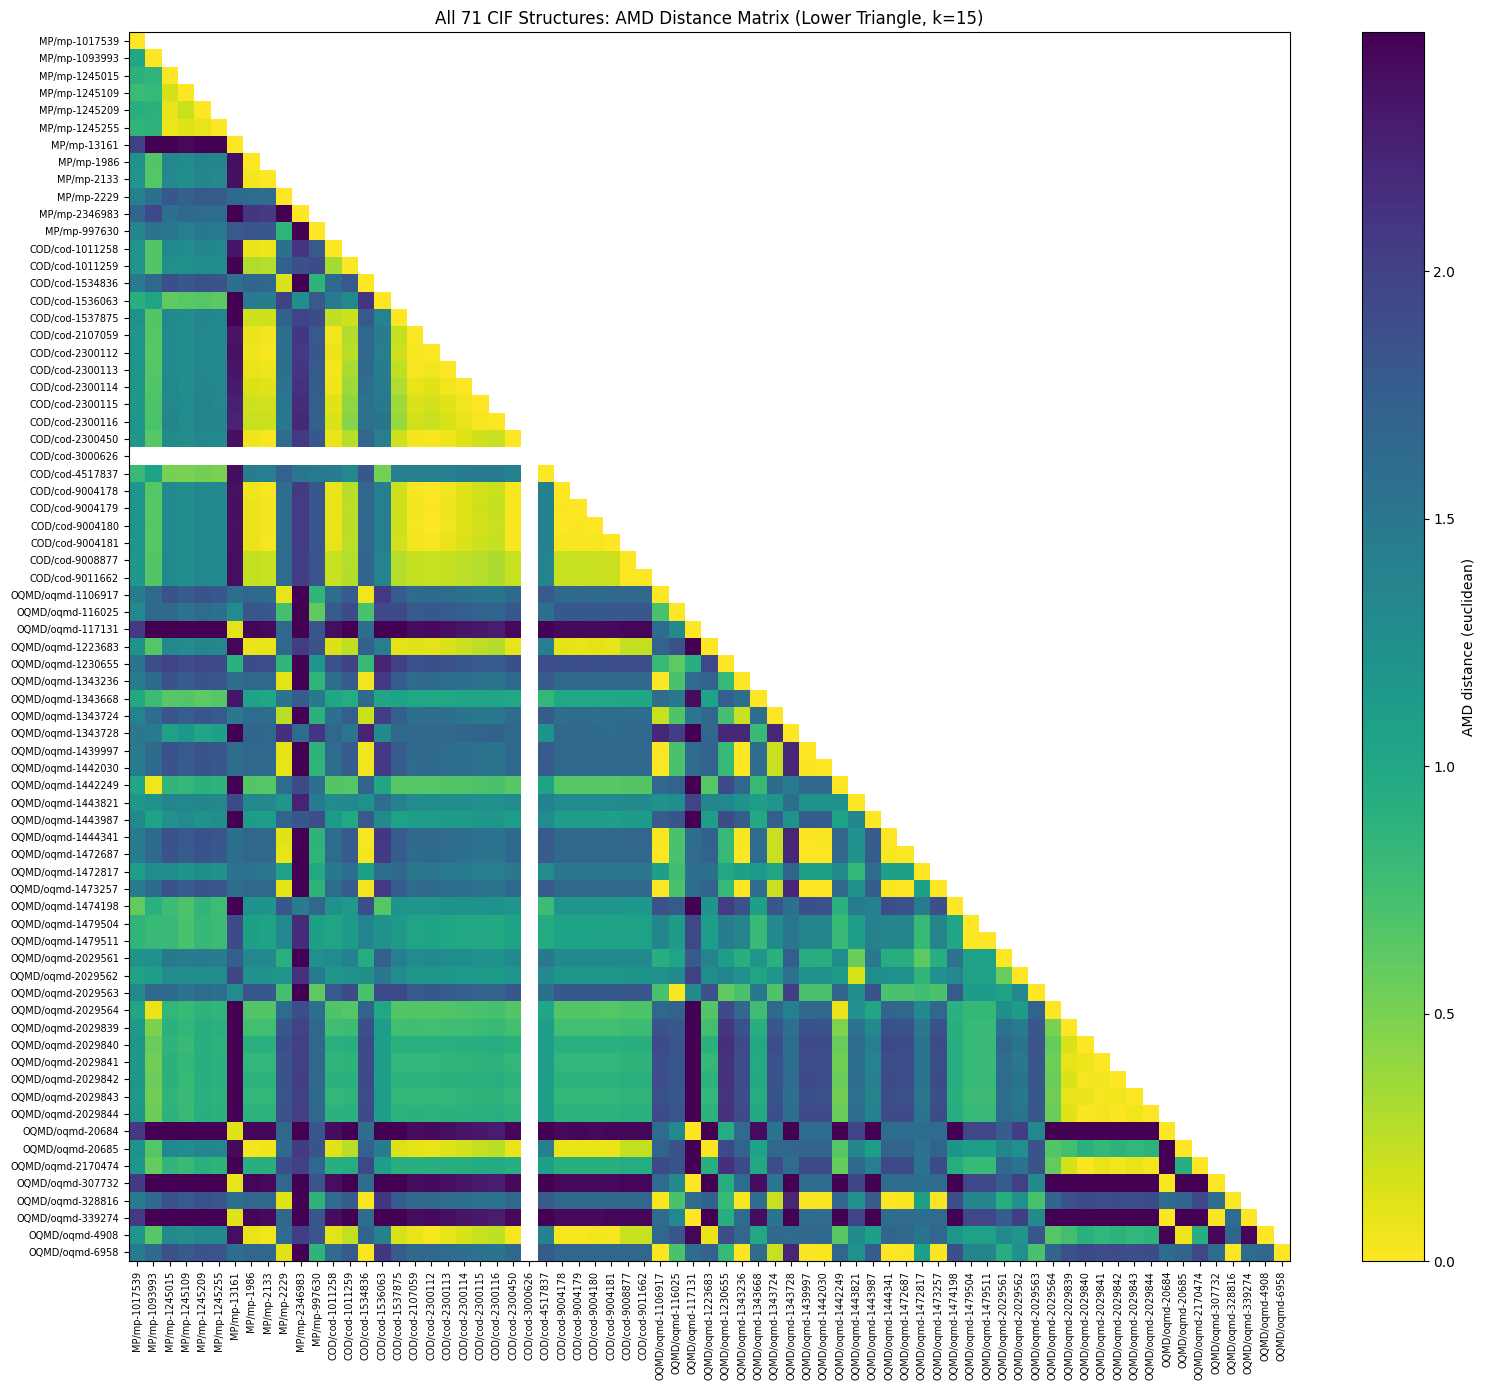

Heatmap saved to    : /home/soe/EMOS/Features/Materials_Exploration/AmdScreening/analysis/results_v2/all_71_amd_distance_matrix_lower_triangle.png


In [4]:
# Keep only the lower triangle (including diagonal) and mask the upper triangle.
upper_triangle_mask = np.triu(np.ones_like(amd_matrix, dtype=bool), k=1)
amd_lower_triangle = np.ma.array(amd_matrix, mask=upper_triangle_mask)

finite_amd = amd_lower_triangle.compressed()
finite_amd = finite_amd[np.isfinite(finite_amd) & (finite_amd > 0)]
vmax = float(np.percentile(finite_amd, 95)) if finite_amd.size else 1.0

cmap = plt.cm.viridis_r.copy()
cmap.set_bad(color='white', alpha=0.0)

fig, ax = plt.subplots(figsize=(16, 14))
image = ax.imshow(amd_lower_triangle, cmap=cmap, aspect='auto', vmin=0, vmax=vmax)
fig.colorbar(image, ax=ax, label=f'AMD distance ({AMD_METRIC})')
ax.set_xticks(range(len(all_labels)))
ax.set_yticks(range(len(all_labels)))
ax.set_xticklabels(all_labels, rotation=90, fontsize=7)
ax.set_yticklabels(all_labels, fontsize=7)
ax.set_title('All 71 CIF Structures: AMD Distance Matrix (Lower Triangle, k=15)')
plt.tight_layout()

plot_path = RESULTS_DIR / 'all_71_amd_distance_matrix_lower_triangle.png'
fig.savefig(plot_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Heatmap saved to    : {plot_path}')